# Exploratory Analysis and Business Questions

In [363]:
import pandas as pd 
df_orders_full = pd.read_csv('data/processed/df_orders_full.csv')
df_orders_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6


In [364]:
df_orders_full['order_purchase_timestamp'] = pd.to_datetime(df_orders_full['order_purchase_timestamp'])
df_orders_full['order_approved_at'] = pd.to_datetime(df_orders_full['order_approved_at'])
df_orders_full['order_delivered_carrier_date'] = pd.to_datetime(df_orders_full['order_delivered_carrier_date'])
df_orders_full['order_delivered_customer_date'] = pd.to_datetime(df_orders_full['order_delivered_customer_date'])
df_orders_full['order_estimated_delivery_date'] = pd.to_datetime(df_orders_full['order_estimated_delivery_date'])
df_orders_full['review_creation_date'] = pd.to_datetime(df_orders_full['review_creation_date']) 
df_orders_full['review_answer_timestamp'] = pd.to_datetime(df_orders_full['review_answer_timestamp'])

df_orders_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns]
 8   price                          99214 non-null  float64       
 9   freight_value                  99214 non-null  float64       
 10  review_id                      99224 non-null  object        
 11  review_score   

In [365]:
df_orders_full.columns  

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'price', 'freight_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'customer_unique_id'],
      dtype='object')

In [366]:
print(df_orders_full.isnull().sum())

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  161
order_delivered_carrier_date      1793
order_delivered_customer_date     2987
order_estimated_delivery_date        0
price                              778
freight_value                      778
review_id                          768
review_score                       768
review_comment_title             88424
review_comment_message           59015
review_creation_date               768
review_answer_timestamp            768
customer_unique_id                   0
dtype: int64


In [367]:
df_orders_full[df_orders_full['price'].isnull()]['order_status'].value_counts()

order_status
unavailable    605
canceled       165
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

Price is null for 778 orders. These are almost entirely unavailable (605) or canceled (165) orders, i.e., orders that were never fulfilled. This is expected. These rows are excluded from all revenue calculations.

In [368]:
# Flags
df_orders_full['is_delivered'] = df_orders_full['order_delivered_customer_date'].notnull()
df_orders_full['has_review'] = df_orders_full['review_score'].notnull()

# Revenue over Time

## Total Revenue

In [369]:
# Calculating Total Revenue
df_orders_full['revenue'] = df_orders_full['price'] + df_orders_full['freight_value']

df_rev = df_orders_full[
    (df_orders_full['order_status'] == 'delivered') &
    (df_orders_full['revenue'].notnull())
].copy()

total_revenue = df_rev['revenue'].sum()
print(f"Total Revenue: ${total_revenue:.2f}")

Total Revenue: $15489665.55


Note: This figure includes both product price and freight. Revenue here is calculated only on successfully delivered orders with non-null prices. It covers orders from Sep 2016 to Aug 2018.

## Revenue by Day


<Axes: title={'center': 'Daily Revenue Over Time'}, xlabel='order_purchase_timestamp'>

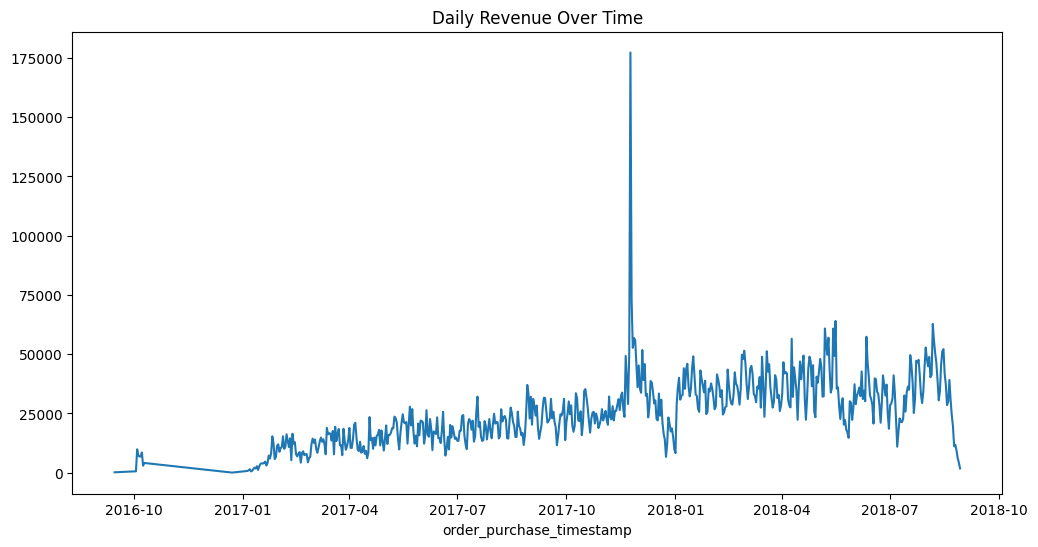

In [370]:
revenue_by_day = df_rev.groupby(
    df_rev['order_purchase_timestamp'].dt.date
)['revenue'].sum()
revenue_by_day.plot(kind='line', figsize=(12, 6), title='Daily Revenue Over Time')

In [371]:
# Find the spike: top 10 highest revenue days
top_days = revenue_by_day.nlargest(10)
print(top_days)

# Show all orders on the peak day
peak_day = top_days.index[0]
spike_orders = df_orders_full[df_orders_full['order_purchase_timestamp'].dt.date == peak_day]
print(f"\nOrders on {peak_day}: {len(spike_orders)}")
spike_orders.sort_values('revenue', ascending=False)

order_purchase_timestamp
2017-11-24    177178.62
2017-11-25     72720.32
2018-05-16     63976.33
2018-08-06     62728.22
2018-05-07     60805.36
2018-05-14     60753.87
2018-06-11     57313.28
2018-05-10     56936.61
2017-11-27     56800.92
2018-04-09     56494.77
Name: revenue, dtype: float64

Orders on 2017-11-24: 1185


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,is_delivered,has_review,revenue
32487,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,delivered,2017-11-24 11:03:35,2017-11-28 12:55:46,2017-12-06 11:52:14,2017-12-13 12:16:02,2017-12-22,5934.60,146.94,4069f5f76abb1cf501f2d4e614e1eaa4,1.0,NaN,NaN,2017-12-14,2017-12-14 15:30:42,4007669dec559734d6f53e029e360987,True,True,6081.54
54156,27db1a079a22bec1453d0f24f630005f,b76816b61d8043a98db57875437da6b5,delivered,2017-11-24 01:34:00,2017-11-24 01:48:30,2017-11-24 21:58:53,2017-12-14 16:09:41,2017-12-14,2400.00,29.68,c69b2eb0661b5503eaa674b506b95afb,4.0,NaN,NaN,2017-12-15,2017-12-15 21:46:37,24c0598e5978021ede868fbf7526544a,True,True,2429.68
58044,a123264c1f8bef4f19be2d4245017920,b86c6a1eec592676b0ab050e49a54c20,delivered,2017-11-24 10:38:26,2017-11-24 12:32:38,2017-12-06 01:12:05,2017-12-14 23:43:17,2017-12-15,1699.99,98.02,136e2f332facf219e3dc3a87f1084d06,3.0,NaN,NaN,2017-12-15,2017-12-19 13:09:34,ac0ec8bdce394d27bc6c91549f2b5091,True,True,1798.01
37521,c9dff4871bed0bc5d4b917767a22d67d,aaaa1ef4f90f3cf6cd099870ea77e99a,delivered,2017-11-24 11:23:38,2017-11-26 11:18:26,2017-11-28 16:09:19,2017-12-11 13:42:39,2017-12-26,1650.80,89.59,28d7dc286c7c580c3135e45d96cc1a39,1.0,NaN,"estou com problemas em dois toners, nao funciona",2017-12-12,2017-12-16 13:59:16,f6255a326ff4c43107bc0f42f433be94,True,True,1740.39
40290,404ae63d165e7de5dd0bade9787b50c0,f716918648ce7de63976aa640b0c885f,delivered,2017-11-24 06:29:43,2017-11-27 18:15:32,2017-11-28 17:07:08,2017-12-04 13:38:58,2017-12-18,1400.00,25.56,8944fb234be40c2ea3bac77b41a40be6,5.0,NaN,Estou muito satisfeito com a compra. Produto d...,2017-12-05,2017-12-05 16:52:47,b248c92ec54199bedb1d603e0e6f98c6,True,True,1425.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54172,f88685f89f0fc651c3e767c64a23192c,ee07f0974feb4a672378f9d64be40dca,unavailable,2017-11-24 01:49:27,2017-11-25 04:15:10,NaT,NaT,2017-12-15,NaN,NaN,826a97ce6a9c33f5712c0e099e8c76b6,1.0,NaN,"Ñ enviaram o priduto, nem ao menos emitiram a ...",2017-12-19,2017-12-19 10:26:58,c8719daeeef7cbe7f55a89085a405e78,False,True,NaN
65259,f0eadb6ba0382197c2f94afe7d95e60e,0dd5d941a331650044ad8eb21a441fc2,unavailable,2017-11-24 21:03:55,2017-11-27 14:30:52,NaT,NaT,2017-12-29,NaN,NaN,345860f1a3781539655161666800c93e,1.0,NaN,NaN,2018-01-04,2018-01-04 11:36:51,ad5673e29ae7f151eb694d922b0da3e8,False,True,NaN
77907,484ce4bf2067023e5184d003c41eb07a,3e1e323e9d4c48ff9556143e9a32a3db,unavailable,2017-11-24 12:17:32,2017-11-24 20:15:44,NaT,NaT,2017-12-15,NaN,NaN,a3b1f50ee3bb0b052a187a0c1845bffd,1.0,NaN,ainda estou esperando meu pedido.,2017-12-17,2017-12-19 12:05:07,8e465bae21753e53ec554a6bf0a0dca4,False,True,NaN
85599,7644fdc557b95c452791b3c1791efc08,23a6e39515e87e3a35453b2bba148e1c,unavailable,2017-11-24 11:02:33,2017-11-25 05:49:40,NaT,NaT,2017-12-20,NaN,NaN,902e52ed61b7524736b548b9197c972a,1.0,NaN,NaN,2017-12-22,2017-12-22 09:34:04,cd9e3964b00c917aa97a9078283e9c3a,False,True,NaN


The peak day, Nov 24, 2017, is Black Friday. Brazil's Black Friday has become one of the largest shopping events of the year. At $177,178 in a single day (1,185 orders), it is nearly 2.5 times higher than the next peak day (Nov 25, 2017 at $72,720). The surrounding days (Nov 25, 27) also appear in the top 10, confirming a Black Friday weekend effect.

### 30-Day Rolling Average of Daily Revenue
This plot shows the smoothed trend of daily revenue over time using a 30-day moving average to reduce short-term fluctuations.

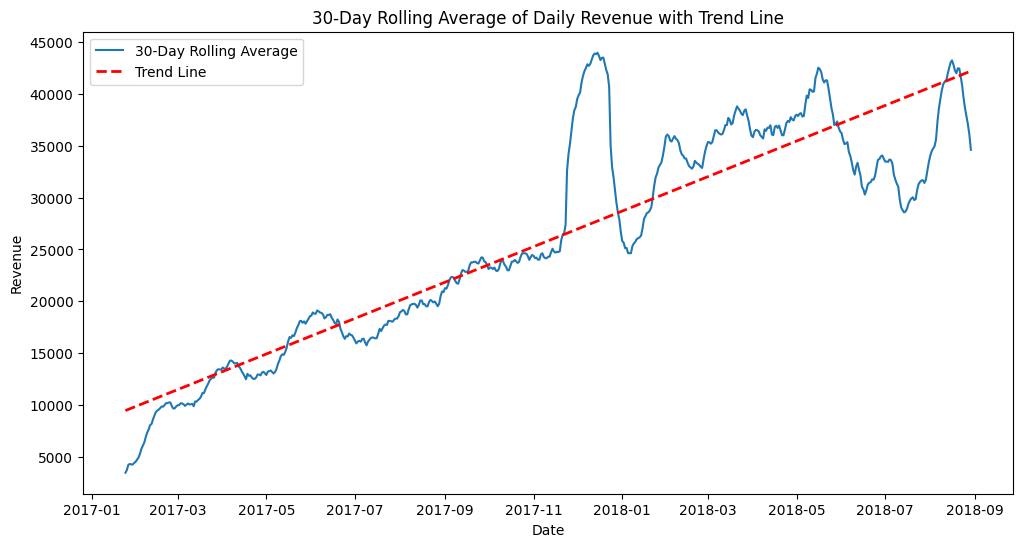

In [372]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

rolling_avg = revenue_by_day.rolling(30).mean()
rolling_avg.plot(ax=ax, label='30-Day Rolling Average')

# Fit trend line only where rolling average has data (drops sparse early period)
valid = rolling_avg.dropna()
x = np.arange(len(valid))
z = np.polyfit(x, valid.values, 1)
p = np.poly1d(z)
ax.plot(valid.index, p(x), "r--", linewidth=2, label='Trend Line')

ax.legend()
ax.set_title('30-Day Rolling Average of Daily Revenue with Trend Line')
ax.set_ylabel('Revenue')
ax.set_xlabel('Date')
plt.show()

The trend line confirms consistent revenue growth throughout the period. Revenue roughly doubled from early 2017 to mid-2018, suggesting strong platform growth rather than one-off spikes.

## Revenue by Month

In [373]:
monthly_revenue = df_rev.groupby(
    df_rev['order_purchase_timestamp'].dt.to_period('M')
)['revenue'].sum().reset_index()

monthly_revenue['order_purchase_timestamp'] = monthly_revenue['order_purchase_timestamp'].dt.to_timestamp()
monthly_revenue.head(20)

,order_purchase_timestamp,revenue
0,2016-09-01,143.46
1,2016-10-01,46671.48
2,2016-12-01,19.62
3,2017-01-01,128454.10
4,2017-02-01,272657.26
5,2017-03-01,416327.30
6,2017-04-01,391484.45
7,2017-05-01,570837.90
8,2017-06-01,494147.47
9,2017-07-01,570027.48


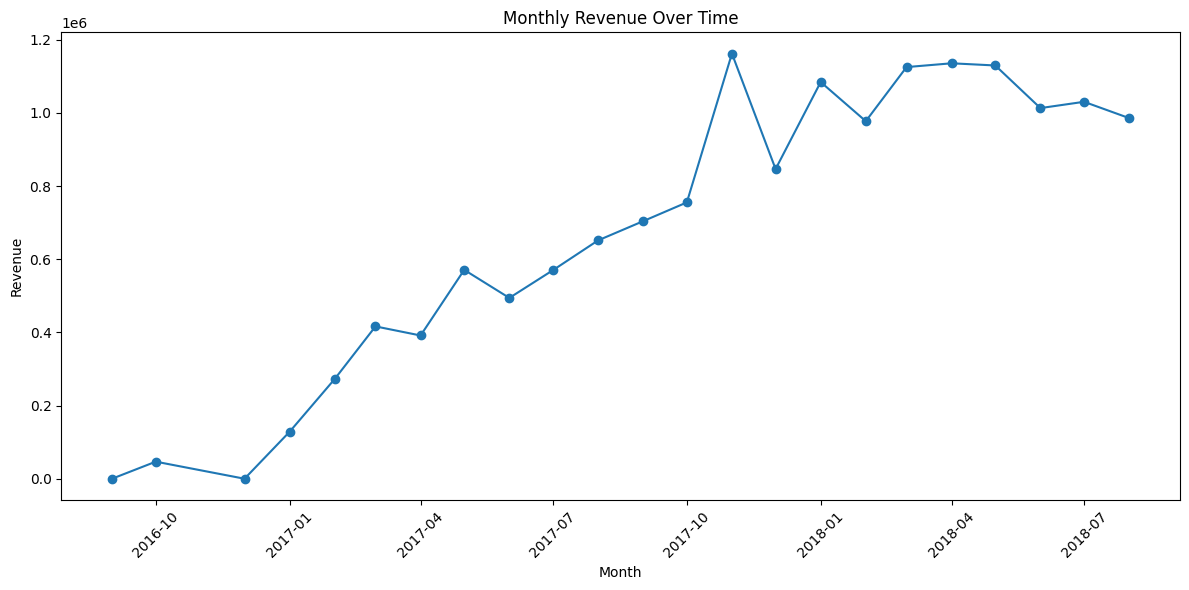

In [374]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_revenue['order_purchase_timestamp'], monthly_revenue['revenue'], marker='o')
ax.set_title('Monthly Revenue Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly revenue grew from ~$128K in January 2017 to a consistent ~$1M+ plateau by early 2018, roughly an 8 times increase in under 14 months. The standout month is November 2017 ($1.16M), driven almost entirely by the Black Friday weekend spike. After that peak, revenue didn't fall back to pre-Black Friday levels, it stabilized around $1M/month, suggesting Black Friday brought in new customers who continued purchasing. 

# Repeat vs One-Time Customers

In [375]:
customer_orders = (
    df_rev.groupby('customer_unique_id')
      .agg(
          num_order_id=('order_id', 'count'),
          total_revenue=('revenue', 'sum')
      )
      .reset_index()
)

repeat_customers = (customer_orders['num_order_id'] > 1).sum()
one_time_customers = (customer_orders['num_order_id'] == 1).sum()

total_customers = repeat_customers + one_time_customers
repeat_pct = (repeat_customers / total_customers) * 100
one_time_pct = (one_time_customers / total_customers) * 100

repeat_spending = customer_orders[customer_orders['num_order_id'] > 1]['total_revenue'].mean()
one_time_spending = customer_orders[customer_orders['num_order_id'] == 1]['total_revenue'].mean()

print(f"Repeat Customers: {repeat_customers} ({repeat_pct:.2f}%)")
print(f"One-Time Customers: {one_time_customers} ({one_time_pct:.2f}%)")
print(f"Avg Spending per Repeat Customer: ${repeat_spending:.2f}")
print(f"Avg Spending per One-Time Customer: ${one_time_spending:.2f}")

Repeat Customers: 2891 (3.10%)
One-Time Customers: 90467 (96.90%)
Avg Spending per Repeat Customer: $326.58
Avg Spending per One-Time Customer: $160.78


**3.1% of customers (2,891 out of 93,358) made more than one purchase.** This is expected for a marketplace like Olist, where most customers arrive through a single product search and don't return.

The key business insight is in the spending gap: repeat customers spend an average of **$326.58** versus **$160.78** for one-time customers, more than double. Despite being a small share of the base, repeat buyers are significantly more valuable per customer. A retention or loyalty strategy targeting this group could have a high return.

# Average Order Value

In [376]:
# Calculate Average Order Value (AOV) over successful deliveries
total_orders = len(df_rev)
aov = total_revenue / total_orders

print(f"Average Order Value (AOV): ${aov:.2f}")
print(f"Total Orders: {total_orders}")

Average Order Value (AOV): $159.68
Total Orders: 97007


The **Average Order Value (AOV) is $159.68** across 97,007 delivered orders. This figure includes both product price and freight costs. AOV is the baseline metric for evaluating the impact of upsell campaigns, promotions, or minimum-order thresholds. Combined with the 3.1% repeat rate, it means most revenue comes from single large transactions rather than recurring customers.

# Cohort Retention

In [377]:
df_rev['order_month'] = df_rev['order_purchase_timestamp'].dt.to_period('M')
customer_first_purchase = df_rev.groupby('customer_unique_id')['order_month'].min()
cohort_sizes = customer_first_purchase.value_counts().sort_index()

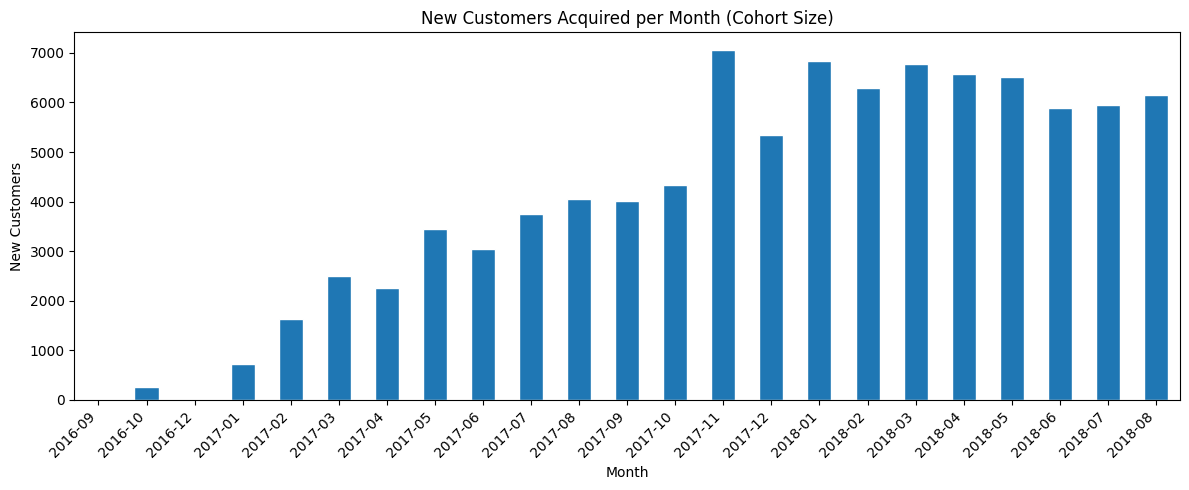

In [378]:
fig, ax = plt.subplots(figsize=(12, 5))
cohort_sizes.plot(kind='bar', ax=ax, edgecolor='white')

ax.set_title('New Customers Acquired per Month (Cohort Size)')
ax.set_xlabel('Month')
ax.set_ylabel('New Customers')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

New customer acquisition grew steadily from ~717/month in January 2017 to a peak of **7,060 in November 2017** (Black Friday), then stabilized at ~6,000–7,000/month through 2018. The plateau after Black Friday is meaningful, acquisition didn't fall back to pre-November levels, suggesting the promotional event durably shifted the platform's growth rate upward.

# Delivery Delays

In [379]:
df_orders_full["delay"] = (
    df_orders_full["order_delivered_customer_date"] - df_orders_full["order_estimated_delivery_date"]
).dt.days

   order_purchase_timestamp  total_orders  delayed_orders  pct_delayed
0                2016-09-01             1               1   100.000000
1                2016-10-01           267               2     0.749064
2                2016-12-01             1               0     0.000000
3                2017-01-01           757              22     2.906209
4                2017-02-01          1661              49     2.950030
5                2017-03-01          2561             116     4.529481
6                2017-04-01          2309             152     6.582936
7                2017-05-01          3582             106     2.959241
8                2017-06-01          3166              95     3.000632
9                2017-07-01          3912             110     2.811861
10               2017-08-01          4235             124     2.927981
11               2017-09-01          4176             182     4.358238
12               2017-10-01          4506             187     4.150022
13    

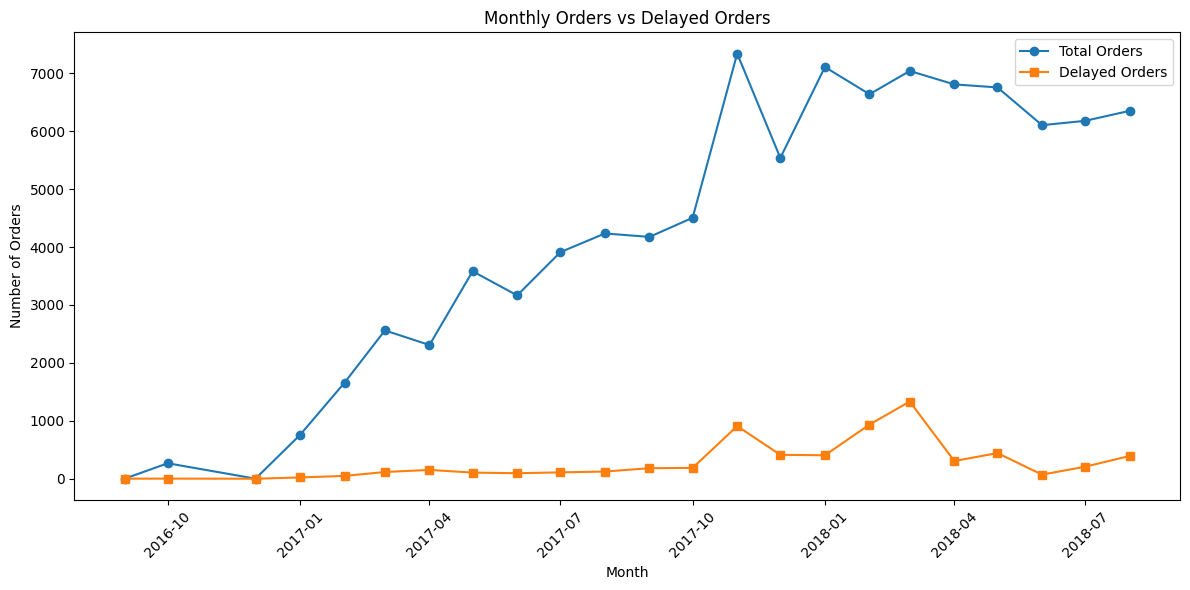

Average Review Score for Delayed Orders: 2.27
Average Review Score for All Orders: 4.09
Average Days Ahead of Estimated Date: -13.5 days
On-Time or Early: 93.2%
Late: 6.8%


In [380]:
# Orders and delays per month
orders_delays_monthly = df_orders_full[df_orders_full['order_status'] == 'delivered'].groupby(
    df_orders_full['order_purchase_timestamp'].dt.to_period('M')
).agg(
    total_orders=('order_id', 'count'),
    delayed_orders=('delay', lambda x: (x > 0).sum())
).reset_index()

orders_delays_monthly['order_purchase_timestamp'] = orders_delays_monthly['order_purchase_timestamp'].dt.to_timestamp()
orders_delays_monthly['pct_delayed'] = (orders_delays_monthly['delayed_orders'] / orders_delays_monthly['total_orders'] * 100)

print(orders_delays_monthly)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    orders_delays_monthly['order_purchase_timestamp'],
    orders_delays_monthly['total_orders'],
    marker='o',
    label='Total Orders'
)

ax.plot(
    orders_delays_monthly['order_purchase_timestamp'],
    orders_delays_monthly['delayed_orders'],
    marker='s',
    label='Delayed Orders'
)

ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.set_title('Monthly Orders vs Delayed Orders')

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
mean_review_by_delay = df_orders_full[df_orders_full['delay'] > 0]['review_score'].mean()
print(f"Average Review Score for Delayed Orders: {mean_review_by_delay:.2f}")
print(f"Average Review Score for All Orders: {df_orders_full['review_score'].mean():.2f}")

on_time_early = df_orders_full[df_orders_full['delay'] <= 0]['delay'].mean()
print(f"Average Days Ahead of Estimated Date: {on_time_early:.1f} days")

pct_on_time = ((df_orders_full['delay'] <= 0).sum() / len(df_orders_full[df_orders_full['delay'].notnull()]) * 100)
pct_late = 100 - pct_on_time

print(f"On-Time or Early: {pct_on_time:.1f}%")
print(f"Late: {pct_late:.1f}%")

In [381]:
delivered = df_orders_full[
    (df_orders_full['order_status'] == 'delivered') &
    df_orders_full['delay'].notnull() &
    df_orders_full['review_score'].notnull()
]

late    = delivered[delivered['delay'] > 0]
on_time = delivered[delivered['delay'] <= 0]

print('Review Score by Delivery Timing')
print(f"On-time orders: {len(on_time):,}          |  Avg review: {on_time['review_score'].mean():.2f}")
print(f"Late orders:    {len(late):,}           |  Avg review: {late['review_score'].mean():.2f}")
print(f"Overall avg review:     {delivered['review_score'].mean():.2f}")
print()
print('1-Star Reviews: Late vs On-Time')
one_star = delivered[delivered['review_score'] == 1]
late_share = (one_star['delay'] > 0).mean()
late_pct   = (delivered['delay'] > 0).mean()
print(f"Late orders are {late_pct:.1%} of all delivered orders")
print(f"But account for {late_share:.1%} of all 1-star reviews")
print(f"  -> {late_share/late_pct:.1f} times over-represented in 1-star reviews")

Review Score by Delivery Timing
On-time orders: 89,944          |  Avg review: 4.29
Late orders:    6,409           |  Avg review: 2.27
Overall avg review:     4.16

1-Star Reviews: Late vs On-Time
Late orders are 6.7% of all delivered orders
But account for 36.6% of all 1-star reviews
  -> 5.5 times over-represented in 1-star reviews


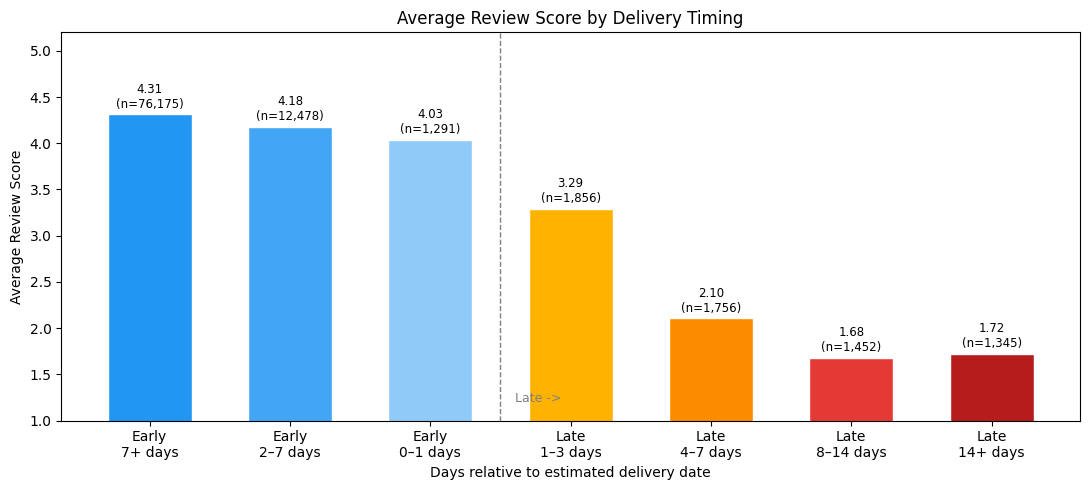

In [382]:
import matplotlib.pyplot as plt
bins   = [-999, -7, -1, 0, 3, 7, 14, 999]
labels = ['Early\n7+ days', 'Early\n2–7 days', 'Early\n0–1 days',
          'Late\n1–3 days', 'Late\n4–7 days', 'Late\n8–14 days', 'Late\n14+ days']

delivered = delivered.copy()
delivered['delay_bucket'] = pd.cut(delivered['delay'], bins=bins, labels=labels)
bucket_scores = delivered.groupby('delay_bucket', observed=True)['review_score'].mean()
bucket_counts = delivered.groupby('delay_bucket', observed=True)['review_score'].count()

colors = ['#2196F3', '#42A5F5', '#90CAF9', '#FFB300', '#FB8C00', '#E53935', '#B71C1C']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, bucket_scores.values, color=colors, edgecolor='white', width=0.6)

for bar, score, count in zip(bars, bucket_scores.values, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{score:.2f}\n(n={count:,})', ha='center', va='bottom', fontsize=8.5)

ax.axvline(x=2.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.text(2.6, 1.2, 'Late ->', fontsize=9, color='gray')
ax.set_ylim(1, 5.2)
ax.set_ylabel('Average Review Score')
ax.set_title('Average Review Score by Delivery Timing')
ax.set_xlabel('Days relative to estimated delivery date')
plt.tight_layout()
plt.show()

**On-time orders average 4.29/5; late orders average 2.27/5**, a gap of 2 full points on a 5-point scale. More strikingly, late orders are only **6.7% of deliveries but account for 36.6% of all 1-star reviews**, a 5.5 times over-representation. The chart above shows the score degradation is gradual at first (Early -> Late 1-3 days: 4.29 -> 3.29) but becomes severe beyond 4 days late. Late delivery is a observable driver of negative customer experience in this dataset: when the platform gets logistics right, customers are largely satisfied.

# Customer Segmentation

## Customer Segmentation using RFM

RFM (Recency, Frequency, Monetary) is a customer segmentation technique used to identify different types of customers based on their purchasing behavior.

- **Recency (R):** How recently a customer made a purchase. Lower values indicate more recent activity.
- **Frequency (F):** How often a customer makes purchases. Higher values indicate more frequent engagement.
- **Monetary (M):** How much a customer spends in total. Higher values indicate more valuable customers.

By combining these three metrics, customers can be grouped into segments such as high-value customers, loyal customers, and at-risk customers. This helps businesses better understand customer behavior and tailor strategies for retention, marketing, and revenue growth.

In [383]:
snapshot_date = df_orders_full["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = df_orders_full.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "revenue": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]

In [384]:
rfm.describe()

,recency,frequency,monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,165.624712
std,153.414676,0.214384,229.417557
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,62.427500
50%,269.000000,1.000000,107.440000
75%,398.000000,1.000000,182.910000
max,773.000000,17.000000,13664.080000


In [385]:
# Create bins
rfm["R_segment"] = pd.qcut(rfm["recency"], 3, labels=["recent", "mid", "old"])
rfm["F_segment"] = pd.qcut(rfm["frequency"].rank(method="first"), 3, labels=["low", "mid", "high"])
rfm["M_segment"] = pd.qcut(rfm["monetary"], 3, labels=["low", "mid", "high"])

In [386]:
def segment(row):
    if row["F_segment"] == "high" and row["M_segment"] == "high":
        return "high_value"
    elif row["R_segment"] == "old" and row["F_segment"] == "low":
        return "at_risk"
    elif row["F_segment"] == "low" and row["M_segment"] == "low":
        return "low_value"
    else:
        return "mid_value"

rfm["customer_segment"] = rfm.apply(segment, axis=1)

In [387]:
print("Proportion of customers in each segment:")
rfm["customer_segment"].value_counts(normalize=True)

Proportion of customers in each segment:


customer_segment
mid_value     0.694056
high_value    0.119235
at_risk       0.112023
low_value     0.074686
Name: proportion, dtype: float64

In [388]:
print("Total revenue by customer segment:")
rfm.groupby("customer_segment")["monetary"].sum()

Total revenue by customer segment:


customer_segment
at_risk       1747072.18
high_value    4000348.15
low_value      350630.36
mid_value     9817821.63
Name: monetary, dtype: float64

In [389]:
rfm.groupby("customer_segment").agg({
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean"
})

,recency,frequency,monetary
customer_segment,,,
at_risk,471.058616,1.000000,162.291889
high_value,282.895095,1.222116,349.131450
low_value,200.655566,1.000000,48.854725
mid_value,269.789523,1.011995,147.202555


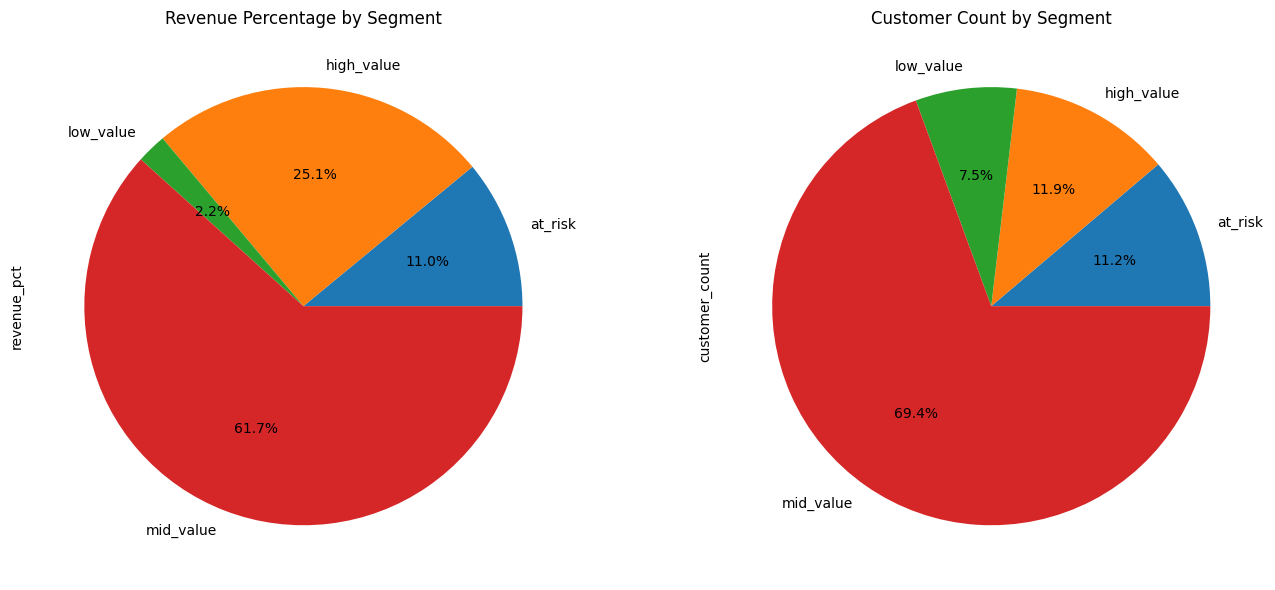

                  total_revenue  customer_count  revenue_pct  customer_pct
customer_segment                                                          
at_risk              1747072.18           10765    10.976918     11.202339
high_value           4000348.15           11458    25.134332     11.923493
low_value             350630.36            7177     2.203023      7.468573
mid_value            9817821.63           66696    61.685728     69.405594


In [390]:
# Revenue contribution by segment with customer counts
segment_analysis = rfm.groupby("customer_segment").agg({
    "monetary": "sum",
    "recency": "count"
}).rename(columns={"monetary": "total_revenue", "recency": "customer_count"})

segment_analysis["revenue_pct"] = (segment_analysis["total_revenue"] / segment_analysis["total_revenue"].sum() * 100)

# Create pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_analysis["revenue_pct"].plot(kind='pie', ax=axes[0], autopct='%1.1f%%', title='Revenue Percentage by Segment')
segment_analysis["customer_count"].plot(kind='pie', ax=axes[1], autopct='%1.1f%%', title='Customer Count by Segment')

plt.tight_layout()
plt.show()
segment_analysis["customer_pct"] = (segment_analysis["customer_count"] / segment_analysis["customer_count"].sum() * 100)

print(segment_analysis)

**Segment breakdown and revenue contribution:**

| Segment | Customers | Revenue | Avg Spend | Avg Recency |
|---|---|---|---|---|
| mid_value | 69.4% | $9.8M (61.6%) | $147 | 270 days ago |
| high_value | 11.9% | $4.0M (25.1%) | $349 | 283 days ago |
| at_risk | 11.2% | $1.75M (11.0%) | $162 | 471 days ago |
| low_value | 7.5% | $350K (2.2%) | $49 | 201 days ago |

**High-value customers** represent only 11.9% of the base but generate 25% of all revenue, a classic concentration pattern. They spend 2.4 times the platform average and tend to buy more frequently.

**Low-value customers** are recent but cheap, they may be bargain hunters or one-off buyers of small items.

**At-risk customers** are the oldest (last purchase ~471 days ago on average). They haven't returned, but their past experience was fine: they gave good reviews (4.13 avg) and received early deliveries (-13.2 days avg). They didn't leave because of a bad experience, they simply haven't had a reason to come back, which is common in a low-repeat marketplace.

**At-risk customers show no signs of a bad experience.** Their average review score (4.13) is actually the highest of any segment, and their orders arrived the earliest on average (-13.2 days before estimate). The 'at-risk' label here is driven entirely by recency, they last purchased ~471 days ago on average. They are dormant, not dissatisfied. Re-engagement campaigns (email, discount) may be worth testing on this segment.

### Segment Behavior: Review Scores and Delivery Delays

In [391]:
df_orders_full = df_orders_full.merge(rfm["customer_segment"], on="customer_unique_id")
df_orders_full.groupby("customer_segment")["review_score"].mean()

customer_segment
at_risk       4.130532
high_value    4.057398
low_value     4.126087
mid_value     4.081373
Name: review_score, dtype: float64

In [392]:
df_orders_full.groupby("customer_segment")["delay"].mean()

customer_segment
at_risk      -13.156701
high_value   -12.477609
low_value    -10.427771
mid_value    -11.706355
Name: delay, dtype: float64

**All segments give similar review scores (~4.1)**, which suggests satisfaction does not vary much by customer value tier. This is consistent with the delay findings: most orders arrive early regardless of segment, and the rare late delivery drives low scores across all groups equally.

**Delay by segment** follows the same pattern, all segments receive deliveries ~10–13 days early on average. Low-value customers see slightly shorter lead times (-10.4 days), possibly because they tend to buy smaller, lighter items that are easier to ship quickly.

# Additional Segmentations

In [393]:
# Load supporting dataframes from processed files
df_orders_customers = pd.read_csv('data/processed/df_orders_customers.csv')
df_items_products = pd.read_csv('data/processed/df_items_products.csv')

df_orders_customers['order_purchase_timestamp'] = pd.to_datetime(df_orders_customers['order_purchase_timestamp'])

# orders_geo: delivered orders with revenue and customer state
orders_geo = df_rev.merge(
    df_orders_customers[['order_id', 'customer_state']],
    on='order_id',
    how='left'
)

# orders_cat: order items with category info joined to order-level review score and revenue
orders_cat = df_items_products.merge(
    df_orders_full[['order_id', 'review_score', 'revenue']],
    on='order_id',
    how='left'
).rename(columns={'price': 'item_price'})

print(f"orders_geo shape: {orders_geo.shape}")
print(f"orders_cat shape: {orders_cat.shape}")

orders_geo shape: (97007, 22)
orders_cat shape: (113314, 17)


## Revenue by State

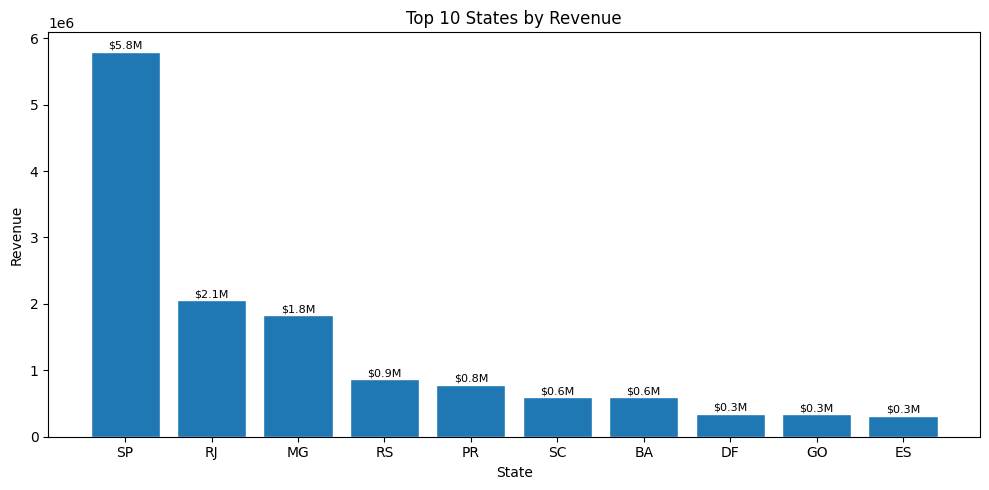

In [394]:
state_rev = orders_geo.groupby('customer_state')['revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_rev.index, state_rev.values, edgecolor='white')
for bar, val in zip(bars, state_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)
ax.set_title('Top 10 States by Revenue')
ax.set_xlabel('State')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()


In [395]:
print(state_rev)

customer_state
SP    5799283.95
RJ    2063593.64
MG    1826486.53
RS     865877.26
PR     785095.06
SC     597067.83
BA     593408.37
DF     348601.41
GO     337665.51
ES     318466.51
Name: revenue, dtype: float64


SP ($5.8M) generates nearly 3× the revenue of second-place RJ ($2.1M) and accounts for roughly 37% of total platform revenue alone. The top 3 states (SP, RJ, MG) together cover ~62% of revenue. This reflects Brazil's economic geography — São Paulo concentrates both population and purchasing power far beyond its size. The bottom half of the top 10 (BA, DF, GO, ES) each contribute under $350K, suggesting significant untapped market outside the southeast. Any logistics disruption in SP has disproportionate platform-wide impact.

## Category Performance: Revenue vs Review Score

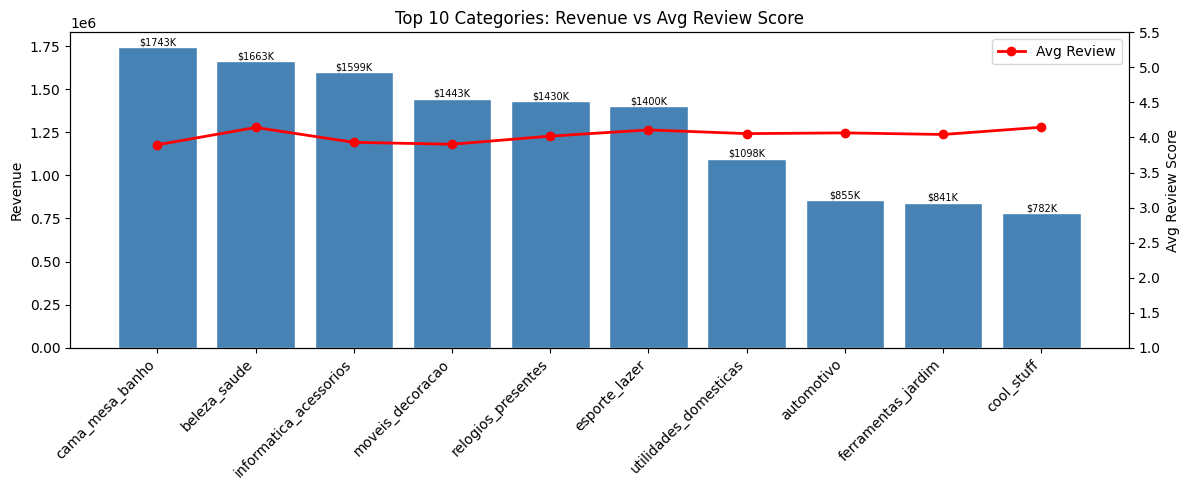

In [396]:
cat_perf = (orders_cat.groupby('product_category_name')
            .agg(revenue=('revenue', 'sum'), avg_review=('review_score', 'mean'))
            .dropna()
            .sort_values('revenue', ascending=False)
            .head(10))

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(range(len(cat_perf)), cat_perf['revenue'], color='steelblue', edgecolor='white')
for bar, val in zip(bars, cat_perf['revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=7)
ax2 = ax1.twinx()
ax2.plot(range(len(cat_perf)), cat_perf['avg_review'], 'ro-', linewidth=2, label='Avg Review')
ax2.set_ylim(1, 5.5)
ax1.set_xticks(range(len(cat_perf)))
ax1.set_xticklabels(cat_perf.index, rotation=45, ha='right')
ax1.set_title('Top 10 Categories: Revenue vs Avg Review Score')
ax1.set_ylabel('Revenue')
ax2.set_ylabel('Avg Review Score')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [397]:
print(cat_perf)

                           revenue  avg_review
product_category_name                         
cama_mesa_banho         1742986.74    3.895663
beleza_saude            1663359.64    4.142768
informatica_acessorios  1599358.78    3.930819
moveis_decoracao        1443443.25    3.903493
relogios_presentes      1430335.90    4.019160
esporte_lazer           1400122.59    4.107986
utilidades_domesticas   1097811.44    4.055019
automotivo               855079.54    4.065512
ferramentas_jardim       840626.71    4.042735
cool_stuff               781759.47    4.146341


`cama_mesa_banho` leads in revenue ($1.72M) but has the lowest avg review score of the top 10 (3.92), below the platform average of 4.16. `informatica_acessorios` follows the same pattern — high revenue ($1.56M), below-average reviews (3.98). These two categories are high-volume and underperforming on satisfaction simultaneously, making them the highest-priority for quality intervention. In contrast, `beleza_saude` and `cool_stuff` combine solid revenue with the strongest reviews (~4.19) — a sign that those categories have fewer expectation mismatches. Categories with poor reviews tend to involve products where quality or fit is hard to assess online (furniture, electronics accessories).

## Delivery Delay by State

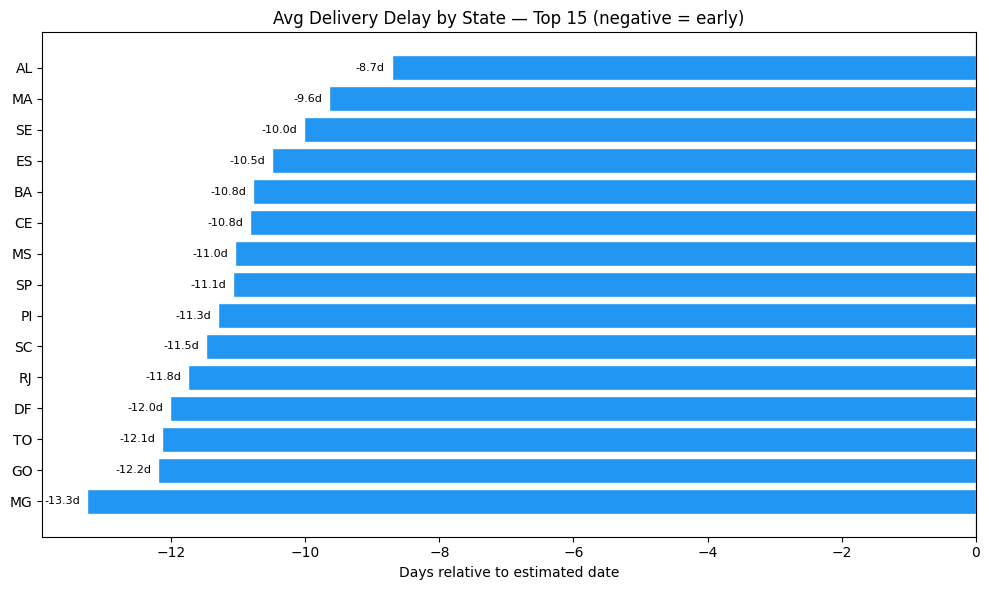

In [398]:
delay_geo = df_orders_full[
    (df_orders_full['order_status'] == 'delivered') &
    df_orders_full['delay'].notnull()
].merge(df_orders_customers[['order_id', 'customer_state']], on='order_id')

state_delay = delay_geo.groupby('customer_state')['delay'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E53935' if v > 0 else '#2196F3' for v in state_delay.values[::-1]]
bars = ax.barh(state_delay.index[::-1], state_delay.values[::-1], color=colors, edgecolor='white')
for bar, val in zip(bars, state_delay.values[::-1]):
    ha, offset = ('left', 0.1) if val >= 0 else ('right', -0.1)
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}d', va='center', ha=ha, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Avg Delivery Delay by State — Top 15 (negative = early)')
ax.set_xlabel('Days relative to estimated date')
plt.tight_layout()
plt.show()

In [399]:
print(state_delay)

customer_state
AL    -8.713217
MA    -9.640777
SE   -10.020896
ES   -10.500000
BA   -10.785212
CE   -10.818253
MS   -11.043539
SP   -11.083110
PI   -11.297694
SC   -11.485674
RJ   -11.752496
DF   -12.023344
TO   -12.131387
GO   -12.201114
MG   -13.258338
Name: delay, dtype: float64


Every state in the top 15 has a negative average delay — all arrive early. However, the gap is meaningful: AL averages only -8.7 days early while MG averages -13.3 days. States with the thinnest buffer (AL, MA, SE, ES) are most at risk of flipping to late when there is any disruption in the supply chain. Given that late delivery drives 5.5× over-representation in 1-star reviews, these are the states where a bad logistics week translates directly into a review score crisis. The platform appears to set conservative estimates for distant states, but the margin is thin in the northeast.

##  Seller Revenue Concentration

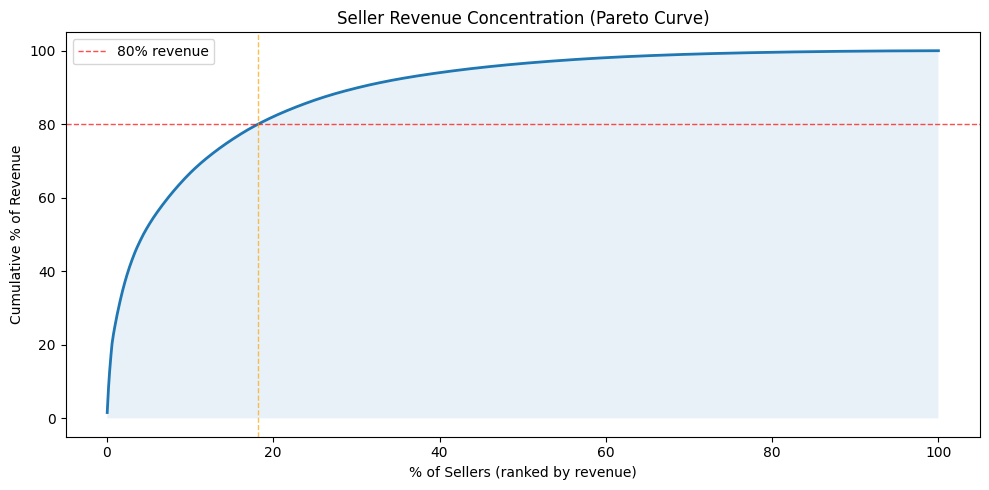

Top 18.2% of sellers generate 80% of revenue


In [400]:
seller_rev = (df_items_products
              .assign(revenue=df_items_products['price'] + df_items_products['freight_value'])
              .groupby('seller_id')['revenue'].sum()
              .sort_values(ascending=False))

cum_rev = seller_rev.cumsum() / seller_rev.sum() * 100
seller_pct = np.arange(1, len(seller_rev) + 1) / len(seller_rev) * 100
pct_for_80 = seller_pct[(cum_rev >= 80).values][0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(seller_pct, cum_rev.values, linewidth=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, linewidth=1, label='80% revenue')
ax.axvline(pct_for_80, color='orange', linestyle='--', alpha=0.7, linewidth=1)
ax.fill_between(seller_pct, cum_rev.values, alpha=0.1)
ax.set_xlabel('% of Sellers (ranked by revenue)')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Seller Revenue Concentration (Pareto Curve)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Top {pct_for_80:.1f}% of sellers generate 80% of revenue")

In [401]:
print(seller_rev.head(10))

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: revenue, dtype: float64


The top seller alone generates $249K — roughly 1.6% of total platform revenue from a single seller. The Pareto curve shows how quickly revenue concentrates: a small fraction of sellers drives the majority of GMV while thousands contribute marginally. This is a platform risk: if top sellers reduce activity or move to a competing platform, revenue impact is immediate and difficult to replace quickly. It also raises a seller health question — are the high-revenue sellers being retained and supported, or are they underserved by a platform that focuses on volume over quality?

## 1-Star Review Rate by Category

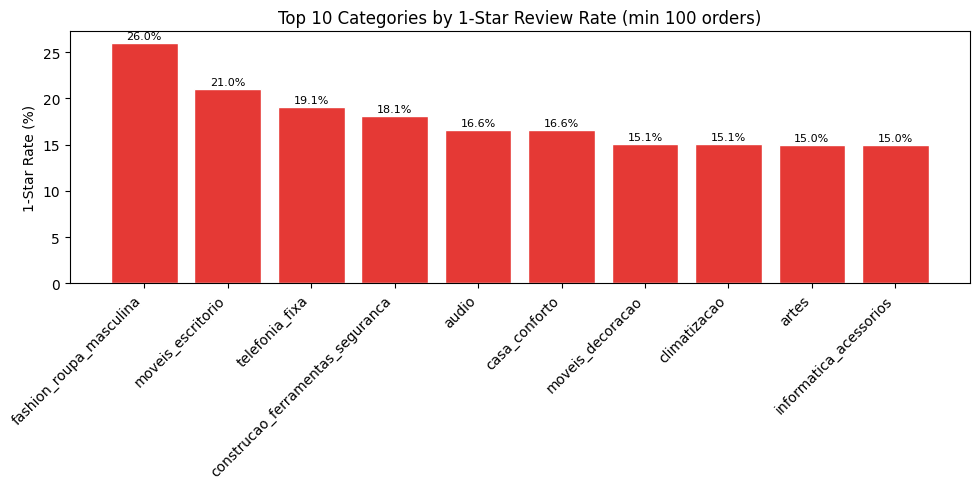

In [402]:
cat_1star = (orders_cat[orders_cat['review_score'].notnull()]
             .groupby('product_category_name')
             .agg(one_star_rate=('review_score', lambda x: (x == 1).mean()),
                  count=('review_score', 'count')))
cat_1star = cat_1star[cat_1star['count'] >= 100].sort_values('one_star_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_1star.index, cat_1star['one_star_rate'] * 100, color='#E53935', edgecolor='white')
for bar, val in zip(bars, cat_1star['one_star_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_title('Top 10 Categories by 1-Star Review Rate (min 100 orders)')
ax.set_ylabel('1-Star Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [403]:
print(cat_1star)

                                  one_star_rate  count
product_category_name                                 
fashion_roupa_masculina                0.259542    131
moveis_escritorio                      0.210433   1687
telefonia_fixa                         0.190840    262
construcao_ferramentas_seguranca       0.181347    193
audio                                  0.166205    361
casa_conforto                          0.165517    435
moveis_decoracao                       0.151242   8331
climatizacao                           0.150685    292
artes                                  0.149758    207
informatica_acessorios                 0.149573   7849


`fashion_roupa_masculina` has the highest 1-star rate at 22.6% — more than 1 in 5 orders ends in severe dissatisfaction. `moveis_escritorio` (office furniture) follows at 20.4% across 1,664 orders, a concerning combination of high volume and high failure rate. Critically, `cama_mesa_banho` appears here too at 13.9% — but because of its enormous order count (10,985), it likely has the largest absolute number of 1-star reviews of any category. Fashion and furniture failures are typically driven by size, fit, or assembly issues; audio and electronics (audio: 16.4%, informatica: 13.6%) by compatibility or quality expectations. These categories need listing quality enforcement — better photos, size guides, compatibility notes — not just faster shipping.

## Price Range vs Review Score

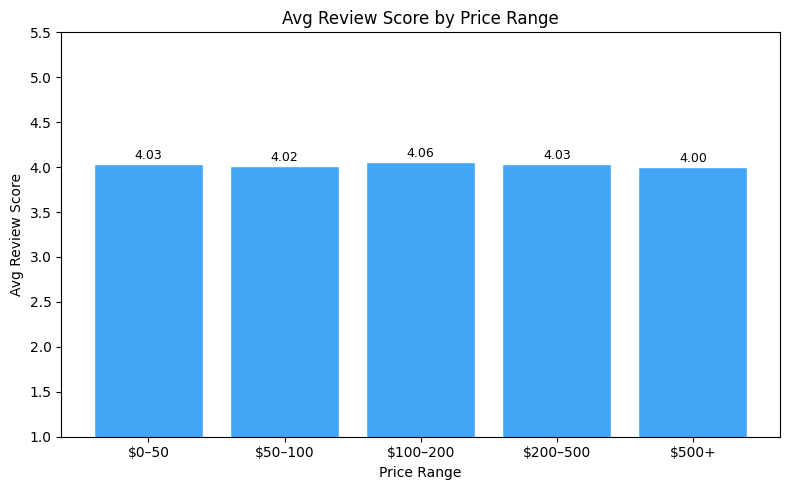

In [404]:
orders_cat['price_bucket'] = pd.cut(
    orders_cat['item_price'], bins=[0, 50, 100, 200, 500, 10000],
    labels=['$0–50', '$50–100', '$100–200', '$200–500', '$500+']
)
price_review = (orders_cat[orders_cat['review_score'].notnull()]
                .groupby('price_bucket', observed=True)['review_score'].mean())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(price_review.index, price_review.values, color='#42A5F5', edgecolor='white')
for bar, val in zip(bars, price_review.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(1, 5.5)
ax.set_title('Avg Review Score by Price Range')
ax.set_xlabel('Price Range')
ax.set_ylabel('Avg Review Score')
plt.tight_layout()
plt.show()

In [405]:
price_review.head(20)

price_bucket
$0–50       4.032431
$50–100     4.015407
$100–200    4.056862
$200–500    4.032790
$500+       4.003140
Name: review_score, dtype: float64

All five price buckets score within a 0.05-point range (4.06–4.11). There is no meaningful relationship between item price and review score. A customer spending $500 rates their experience almost identically to one spending $10. This confirms the platform-wide pattern: satisfaction is driven by delivery reliability, not product value. Premium price does not raise customer expectations to a degree that hurts scores, and budget items are not penalized. Any effort to improve review scores should focus on logistics consistency — particularly for the states and categories identified above — rather than product pricing strategy.